# Electrocardiography Analysis
## Intoduction
An electrocardiogram (ECG) works by using 10–12 adhesive electrodes placed on the skin to detect the tiny electrical impulses generated by the heart's muscle cells during each beat. These signals, representing depolarization and contraction, are amplified by a machine and plotted as a graph (electrocardiogram) over 10 seconds to analyze heart rhythm, speed, and potential structural damage

>### How ECG Technology Functions
>
> - **Electrical Signal Recording**: The heart relies on natural electrical impulses to coordinate contractions. ECG electrodes measure the electrical activity on the skin, which is generated by these cardiac impulses.
> - **Electrode Placement**: In a standard 12-lead ECG, electrodes are placed on the chest, arms, and legs to capture electrical potential from multiple angles, ensuring a comprehensive view of the heart.
> - **Data Capture**: The electrodes are connected to an ECG machine, which records the electrical activity. It is important to lie still, as movement can cause artifacts in the results.Waveform Analysis: The resulting graph consists of waves (P, QRS, and T waves) that correspond to different electrical phases of the heartbeat.
> - **Waveform Analysis**: The resulting graph consists of waves (P, QRS, and T waves) that correspond to different electrical phases of the heartbeat.
> - **Diagnostic Purpose**: ECGs detect arrhythmias (irregular beats), coronary heart disease, and signs of heart attacks.

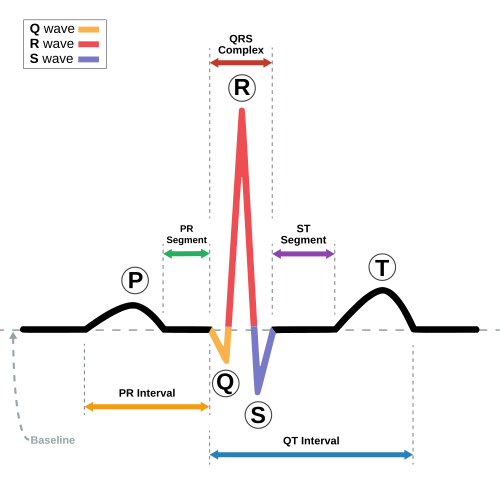

>### Key Components
>
> - **P Wave:** Represents atrial depolarization (contraction of the upper chambers).
> - **PR Interval:** The time taken for the electrical impulse to travel from the atria to the ventricles (from start of P to start of QRS).
> - **QRS Complex:** Represents ventricular depolarization (contraction of the lower, larger chambers).
> - **ST Segment:** Connects the QRS complex and T wave; represents the interval between ventricular depolarization and repolarization (ventricles are contracting but not actively conducting electricity).
> - **T Wave:** Represents ventricular repolarization (relaxation and resetting of the ventricles).
> - **QT Interval:** The time for both ventricular depolarization and repolarization.
> - **U Wave (Optional):** A small deflection sometimes seen after the T wave, associated with papillary muscle repolarization

## Local Extrema Relation
The concept of local extrema (local maxima and minima) from calculus is very useful when analyzing an electrocardiogram (EKG/ECG) signal. An EKG is essentially a time-varying voltage signal produced by the electrical activity of the heart, and many of its key features correspond to local extrema.
An EKG trace can be thought of as a function:
$$ \mathbf{V}(t) $$
> - $t - time$
> - $\mathbf{V}(t) = \text{measured electrical potential}$

Local extrema occur where the derivative is zero or changes sign, meaning the signal reaches a peak or trough.
Local maxima correspond to peaks in the waveform.

Important examples:
> - **R wave peak** – the largest upward spike in the QRS complex
> - **P wave peak** – atrial depolarization
> - **T wave peak** – ventricular repolarization
The R peak is especially important because:
> - It is a **local maximum**.
> - Algorithms detect these maxima to compute **heart rate**.

Example:
If $t_1, t_2, t_3$ are times of R-wave maxima:
$$ \mathbf{Heart Rate} = \frac{60}{t_{i+1} - t_i} $$
Computer algorithms detect extrema by:

1. Calculating the **derivative of the signal**

2. Finding **zero crossings** of the derivative

3. Confirming **max/min using second derivative or thresholds**

This is how wearable devices and monitors automatically read EKG signals.

## Convex / Concave
In an EKG (electrocardiogram), doctors often describe parts of the waveform—especially the ST segment—as convex or concave. These terms come directly from the mathematical idea of convexity/concavity of graphs, and they help clinicians recognize patterns linked to different heart conditions.
In mathematics:
> - **Convex (curving upward like a dome):** the graph bends **upward**.
> - **Concave (curving downward like a bowl):** the graph bends **downward**.

These shapes describe how the curve bends, which mathematically relates to the second derivative (curvature).
If the ST segment bulges upward like a dome, this pattern can suggest acute myocardial infarction (heart attack).
If the ST segment curves upward but scoops inward this pattern is more often seen in benign or non-ischemic conditions, such as: pericarditis and Early repolarization (a normal variant in some people)

## Math analysis
An **electrocardiogram (ECG)** measures the electrical **activity of the heart over time**.
Mathematically, an ECG signal is a **time-series function**:
$$ \mathbf{ECG}(t) $$
Where:
> - t = time
> - $ \mathbf{ECG}(t) $ = electrical potential (mV)

The signal consists of repeating components:

| Wave      | Meaning                  |Mathematical property     |
|-----------|--------------------------|--------------------------|
|P wave     |atrial depolarization     |small amplitude           |
|QRS complex|ventricular depolarization|sharp high-frequency spike|
|T wave     |ventricular repolarization|smooth curve              |

Typical ECG signals contain **noise**, so math tools are used to analyze them.
Main mathematical techniques:
1. Signal filtering
2. Fourier Transform
3. Peak detection
4. Heart rate calculation
5. Statistical analysis

ECG is recorded digitally:
$$ x[n] = \text{ECG}(nT_s) $$
Where:
>- $ T_s $ = sampling period
>- $ f_s = \frac{1}{T_s} $ = sampling frequency (often 250–500 Hz)

Fourier transform is used to analyze signal frequency components.
$$ X(f) = \int_{-\infty}^{\infty} x(t)e^{-i2\pi ft} dt $$

Common ECG filters:
| Filter    | Purpose                     |
| --------- | --------------------------- |
| Low-pass  | remove high-frequency noise |
| High-pass | remove baseline drift       |
| Band-pass | keep useful ECG range       |

Typical ECG frequency band: 0.5−40 Hz

The R peak is the tallest spike in the ECG. It can be used to calculate Heart rate (HR) 
$$ \mathbf{HR} = \frac{60}{\mathbf{RR}} $$

Where:
> - $ \mathbf{RR} $ = = time between consecutive R peaks (seconds)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt

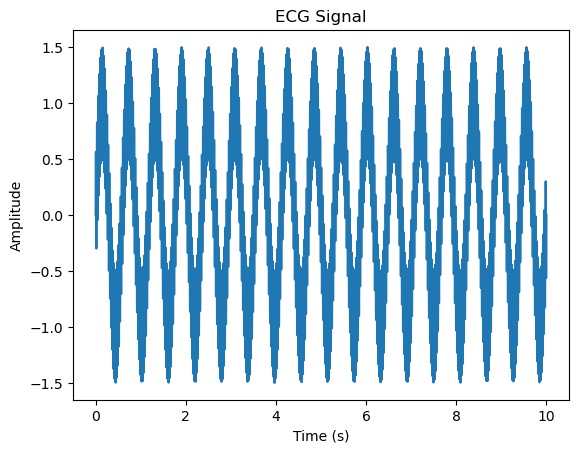

In [8]:
# Generate ECG
t = np.linspace(0,10,5000)
ecg = np.sin(2*np.pi*1.7*t) + 0.5*np.sin(2*np.pi*40*t)
plt.plot(t, ecg)
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [9]:
# Filter ECG
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass_filter(ecg, 0.5, 40, 500)

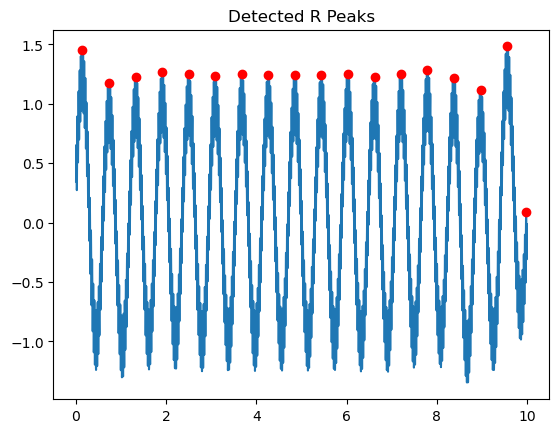

In [10]:
peaks, _ = find_peaks(filtered, distance=200)

plt.plot(t, filtered)
plt.plot(t[peaks], filtered[peaks], "ro")
plt.title("Detected R Peaks")
plt.show()

In [12]:
# Calculate heart rate
rr_intervals = np.diff(t[peaks])
heart_rate = 60 / np.mean(rr_intervals)

print("Heart Rate:", heart_rate, "BPM")

Heart Rate: 103.55361494719739 BPM


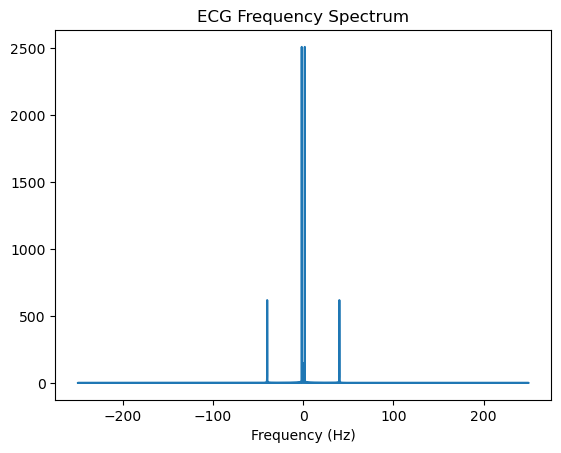

In [13]:
# Fourier analysis
fft = np.fft.fft(filtered)
freq = np.fft.fftfreq(len(filtered), 1/500)

plt.plot(freq, np.abs(fft))
plt.title("ECG Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.show()

## Blood Oxygen Measuring
Blood oxygen saturation (SpO₂) is typically measured using photoplethysmography (PPG) with two wavelengths of light.
> **Principle:**
> - Oxygenated and deoxygenated hemoglobin absorb light differently.
> - Two LEDs are used: Red (\~660 nm) and Infrared (~940 nm)

A sensor measures how much light passes through or reflects from tissue (usually finger or earlobe).
Using the Beer–Lambert Law, the device calculates:
$$ SpO_2 = \frac{HbO_2}{HbO_2 + Hb} $$
An EKG (electrocardiogram) measures: Electrical activity of the heart, heart rhythm, cardiac conduction.
But it contains no optical or chemical information about hemoglobin, so it cannot determine oxygen saturation.
However, it can provide supporting metrics like: Blood volume changes in tissue, pulse waveform and heart rate.
Many Arduino-type pulse sensors measure PPG with a single LED. But with only one wavelength, they cannot separate oxyhemoglobin and deoxyhemoglobin, so they cannot calculate SpO₂. If the sensor includes two LEDs (Red + IR), it becomes a pulse oximeter.
The oxygen calculation is:
$$ R = \frac{(AC_{red} / DC_{red})}{(AC_{IR} / DC_{IR})} $$
Then SpO₂ is approximated with a calibration curve:
$$ SPO_2 \thickapprox 110 - 25R $$